In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_DATA_DIR = Path("../data/raw")

txt_files = list(RAW_DATA_DIR.rglob("*.txt"))
signal_files = [
    f for f in txt_files
    if f.name.startswith(("GaCo", "GaPt", "SiCo", "SiPt", "JuCo", "JuPt"))
]
print("Total txt files:", len(txt_files))
print("Signal files:", len(signal_files))

for f in signal_files[:10]:
    print(f.name)

Total txt files: 309
Signal files: 306
GaCo01_01.txt
GaCo02_01.txt
GaCo02_02.txt
GaCo03_01.txt
GaCo03_02.txt
GaCo04_01.txt
GaCo04_02.txt
GaCo05_01.txt
GaCo05_02.txt
GaCo06_01.txt


In [4]:
def parse_signal_filename(file_path):
    name = file_path.stem
    # Example: GaCo01_01
    
    study_code = name[:2]      # Ga, Si, Ju
    group_code = name[2:4]     # Co or Pt
    subject_number = name[4:6] # 01, 02, 03...
    trial_number = name.split("_")[-1]
    
    group = "Control" if group_code == "Co" else "Parkinson"
    
    return {
        "file_name": file_path.name,
        "file_path": file_path,
        "study": study_code,
        "group": group,
        "subject_id": name.split("_")[0],
        "subject_number": subject_number,
        "trial": trial_number
    }

In [5]:
file_records = [parse_signal_filename(f) for f in signal_files]

file_table = pd.DataFrame(file_records)

file_table.head()

,file_name,file_path,study,group,subject_id,subject_number,trial
0,GaCo01_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo01,01,01
1,GaCo02_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,02,01
2,GaCo02_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,02,02
3,GaCo03_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,03,01
4,GaCo03_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,03,02


In [6]:
file_table["study"].value_counts()

study
Ju    129
Ga    113
Si     64
Name: count, dtype: int64

## Signal file groups

The dataset contains signal files from multiple study groups.  
The file prefixes indicate the source group and health condition.

- `GaCo`: control subject from Ga group
- `GaPt`: Parkinson's patient from Ga group
- `SiCo`: control subject from Si group
- `SiPt`: Parkinson's patient from Si group
- `JuCo`: control subject from Ju group
- `JuPt`: Parkinson's patient from Ju group

This distinction is important because later analysis should check whether observed gait differences are consistent across the different study groups, not only across the full mixed dataset.

In [7]:
file_table["group"].value_counts()

group
Parkinson    214
Control       92
Name: count, dtype: int64

In [8]:
pd.crosstab(file_table["study"], file_table["group"])

group,Control,Parkinson
study,,
Ga,38,75
Ju,25,104
Si,29,35


In [9]:
file_table.groupby("group")["subject_id"].nunique()

group
Control      72
Parkinson    93
Name: subject_id, dtype: int64

In [10]:
file_table.groupby(["study", "group"])["subject_id"].nunique()

study  group    
Ga     Control      18
       Parkinson    29
Ju     Control      25
       Parkinson    29
Si     Control      29
       Parkinson    35
Name: subject_id, dtype: int64

In [11]:
def load_gait_signal(file_path):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    
    columns = (
        ["time"]
        + [f"left_sensor_{i}" for i in range(1, 9)]
        + [f"right_sensor_{i}" for i in range(1, 9)]
        + ["left_total_force", "right_total_force"]
    )
    
    if df.shape[1] != len(columns):
        raise ValueError(
            f"{file_path.name} has {df.shape[1]} columns, "
            f"but expected {len(columns)}"
        )
    
    df.columns = columns
    return df

In [12]:
control_file = file_table[file_table["group"] == "Control"]["file_path"].iloc[0]

control_df = load_gait_signal(control_file)

print(control_file.name)
print(control_df.shape)
control_df.head()

GaCo01_01.txt
(12119, 19)


,time,left_sensor_1,left_sensor_2,left_sensor_3,left_sensor_4,left_sensor_5,left_sensor_6,left_sensor_7,left_sensor_8,right_sensor_1,right_sensor_2,right_sensor_3,right_sensor_4,right_sensor_5,right_sensor_6,right_sensor_7,right_sensor_8,left_total_force,right_total_force
0,0.00,199.1,87.34,91.08,24.09,21.12,87.67,87.23,64.57,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,662.20,748.00
1,0.01,199.1,87.34,91.08,24.09,21.12,87.67,87.23,64.57,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,662.20,748.00
2,0.02,199.1,87.34,91.08,24.09,21.12,87.67,87.23,62.59,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,660.22,748.00
3,0.03,199.1,87.34,91.08,24.09,21.12,87.67,89.10,64.57,163.9,77.55,112.42,48.07,13.75,105.49,144.98,79.53,664.07,745.69
4,0.04,199.1,87.34,91.08,24.09,21.12,87.67,87.23,62.59,163.9,77.55,112.42,50.82,13.75,105.49,144.98,79.53,660.22,748.44


In [13]:
patient_file = file_table[file_table["group"] == "Parkinson"]["file_path"].iloc[0]

patient_df = load_gait_signal(patient_file)

print(patient_file.name)
print(patient_df.shape)
patient_df.head()

GaPt03_01.txt
(12119, 19)


,time,left_sensor_1,left_sensor_2,left_sensor_3,left_sensor_4,left_sensor_5,left_sensor_6,left_sensor_7,left_sensor_8,right_sensor_1,right_sensor_2,right_sensor_3,right_sensor_4,right_sensor_5,right_sensor_6,right_sensor_7,right_sensor_8,left_total_force,right_total_force
0,0.00,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
1,0.01,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
2,0.02,71.72,173.25,134.31,84.92,31.68,64.57,87.78,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.43,0.0
3,0.03,68.53,169.84,132.55,86.46,31.68,67.43,87.78,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.87,0.0
4,0.04,65.34,168.19,132.55,86.46,31.68,67.43,91.52,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,682.77,0.0


In [14]:
def plot_force_zoom(df, title, start_time=20, end_time=30):
    zoom_df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]
    
    plt.figure(figsize=(14, 4))
    plt.plot(zoom_df["time"], zoom_df["left_total_force"], label="Left total force")
    plt.plot(zoom_df["time"], zoom_df["right_total_force"], label="Right total force")
    plt.xlabel("Time (s)")
    plt.ylabel("Force (N)")
    plt.title(title)
    plt.legend()
    plt.show()

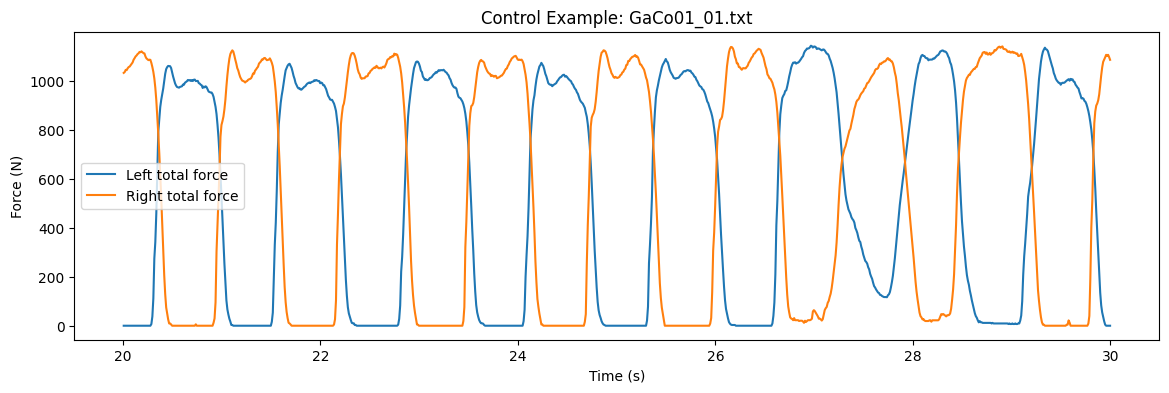

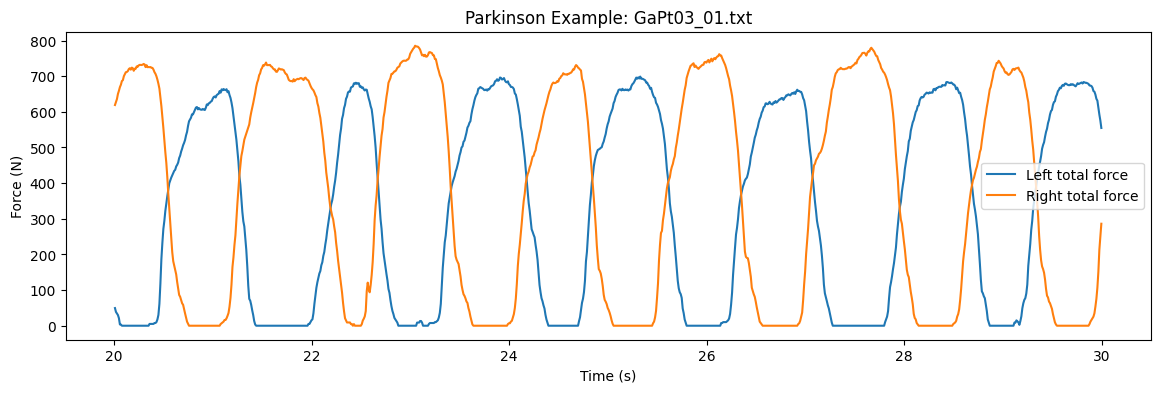

In [15]:
plot_force_zoom(control_df, f"Control Example: {control_file.name}")
plot_force_zoom(patient_df, f"Parkinson Example: {patient_file.name}")

In [16]:
file_table.to_csv("../data/processed/file_table.csv", index=False)

In the selected 10-second window, both examples show alternating left and right foot-force patterns. The control example shows higher and sharper force peaks, while the Parkinson example shows lower peaks and slightly different step shapes. However, this visual difference cannot yet be interpreted as a disease effect, because body weight, walking speed, age, and study group may also influence the force signal.

In [19]:
column_counts = []

for file_path in signal_files:
    temp_df = pd.read_csv(file_path, sep=r"\s+", header=None)
    column_counts.append({
        "file_name": file_path.name,
        "n_rows": temp_df.shape[0],
        "n_columns": temp_df.shape[1]
    })

column_check = pd.DataFrame(column_counts)

column_check.head()

,file_name,n_rows,n_columns
0,GaCo01_01.txt,12119,19
1,GaCo02_01.txt,12119,19
2,GaCo02_02.txt,12119,19
3,GaCo03_01.txt,12119,19
4,GaCo03_02.txt,12119,19


In [20]:
column_check["n_columns"].value_counts()

n_columns
19    306
Name: count, dtype: int64

In [22]:
column_check["n_rows"].describe()

count      306.000000
mean     10841.666667
std       2582.981934
min       4034.000000
25%       9187.000000
50%      12119.000000
75%      12119.000000
max      26366.000000
Name: n_rows, dtype: float64

In [23]:
column_check.to_csv("../data/processed/column_check.csv", index=False)